In [4]:
# === IMPORTS ET CONFIGURATION ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Import des simulateurs du projet
import sys
sys.path.insert(0, '..')

from tandem_queue_simulation import TandemQueueSimulator, run_multiple_simulations
from tandem_queue_finite import FiniteQueueSimulator
from tandem_queue_populations import MultiPopulationSimulator

# Seed pour reproductibilité
np.random.seed(42)

print("✅ Imports réussis - Prêt pour l'analyse !")

✅ Imports réussis - Prêt pour l'analyse !


---

## 1. Introduction et Principe de Superposition {#1-introduction}

### 1.1 Modèle Théorique

Le système est modélisé comme un **réseau de files d'attente en tandem** :

```
Arrivées (λ) → [Station 1: M/M/K] → [Station 2: M/M/1] → Sortie
```

### 1.2 Principe de Superposition des Processus de Poisson

**Théorème** : La superposition de deux processus de Poisson indépendants de taux $\lambda_1$ et $\lambda_2$ est un processus de Poisson de taux $\lambda_1 + \lambda_2$.

Pour le cas "Channels and Dams" avec deux populations :

$$N_{total} = N_{ING} + N_{PREPA} \sim \text{Poisson}(\lambda_{ING} + \lambda_{PREPA})$$

**Conséquence** : On peut analyser le flux total comme un seul processus de Poisson.

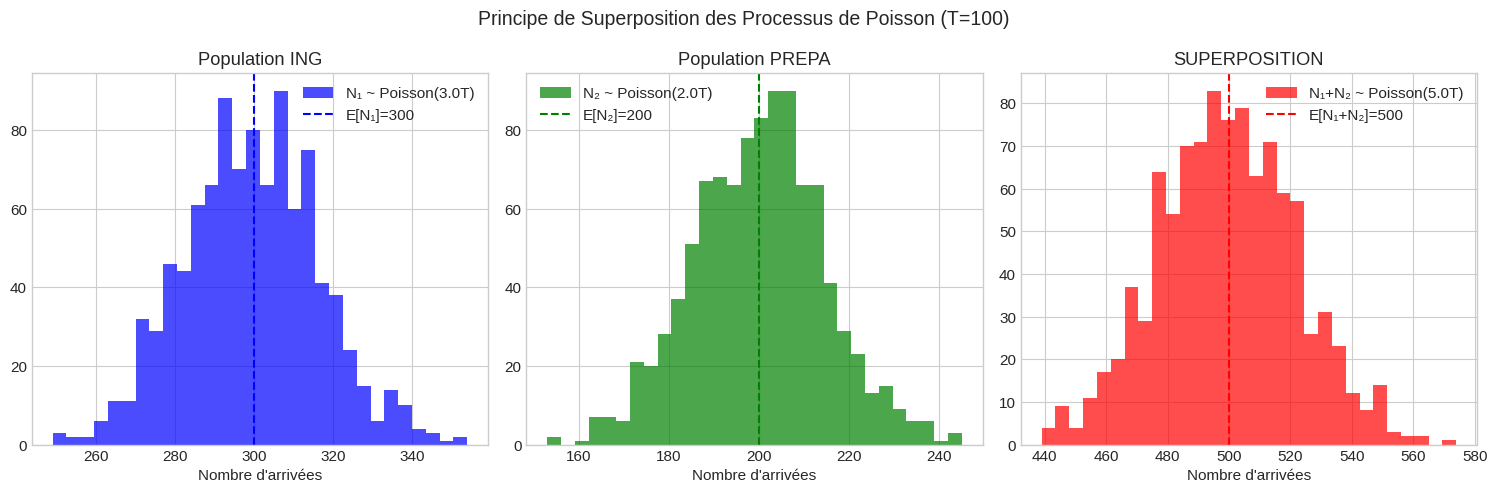


📊 VÉRIFICATION STATISTIQUE:

Population ING (λ₁ = 3.0):
  - Moyenne empirique: 299.04 (théorique: 300.00)
  - Variance empirique: 290.11 (théorique: 300.00)

Population PREPA (λ₂ = 2.0):
  - Moyenne empirique: 200.00 (théorique: 200.00)
  - Variance empirique: 214.11 (théorique: 200.00)

SUPERPOSITION (λ₁ + λ₂ = 5.0):
  - Moyenne empirique: 499.05 (théorique: 500.00)
  - Variance empirique: 497.75 (théorique: 500.00)


In [5]:
# === DÉMONSTRATION DU PRINCIPE DE SUPERPOSITION ===

def demonstrate_superposition(lambda1=3.0, lambda2=2.0, T=100, n_simulations=1000):
    """
    Démontre visuellement le principe de superposition.
    """
    # Simulation de nombreuses trajectoires
    counts_1 = []
    counts_2 = []
    counts_sum = []
    
    for _ in range(n_simulations):
        # Processus 1 (ING)
        n1 = np.random.poisson(lambda1 * T)
        counts_1.append(n1)
        
        # Processus 2 (PREPA)  
        n2 = np.random.poisson(lambda2 * T)
        counts_2.append(n2)
        
        # Superposition
        counts_sum.append(n1 + n2)
    
    # Visualisation
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Histogramme des comptages
    bins = np.arange(min(counts_sum) - 5, max(counts_sum) + 5, 5)
    
    axes[0].hist(counts_1, bins=30, alpha=0.7, label=f'N₁ ~ Poisson({lambda1}T)', color='blue')
    axes[0].axvline(lambda1*T, color='blue', linestyle='--', label=f'E[N₁]={lambda1*T:.0f}')
    axes[0].set_title('Population ING')
    axes[0].set_xlabel('Nombre d\'arrivées')
    axes[0].legend()
    
    axes[1].hist(counts_2, bins=30, alpha=0.7, label=f'N₂ ~ Poisson({lambda2}T)', color='green')
    axes[1].axvline(lambda2*T, color='green', linestyle='--', label=f'E[N₂]={lambda2*T:.0f}')
    axes[1].set_title('Population PREPA')
    axes[1].set_xlabel('Nombre d\'arrivées')
    axes[1].legend()
    
    axes[2].hist(counts_sum, bins=30, alpha=0.7, label=f'N₁+N₂ ~ Poisson({lambda1+lambda2}T)', color='red')
    axes[2].axvline((lambda1+lambda2)*T, color='red', linestyle='--', label=f'E[N₁+N₂]={(lambda1+lambda2)*T:.0f}')
    axes[2].set_title('SUPERPOSITION')
    axes[2].set_xlabel('Nombre d\'arrivées')
    axes[2].legend()
    
    plt.suptitle(f'Principe de Superposition des Processus de Poisson (T={T})', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    print("\n📊 VÉRIFICATION STATISTIQUE:")
    print(f"\nPopulation ING (λ₁ = {lambda1}):")
    print(f"  - Moyenne empirique: {np.mean(counts_1):.2f} (théorique: {lambda1*T:.2f})")
    print(f"  - Variance empirique: {np.var(counts_1):.2f} (théorique: {lambda1*T:.2f})")
    
    print(f"\nPopulation PREPA (λ₂ = {lambda2}):")
    print(f"  - Moyenne empirique: {np.mean(counts_2):.2f} (théorique: {lambda2*T:.2f})")
    print(f"  - Variance empirique: {np.var(counts_2):.2f} (théorique: {lambda2*T:.2f})")
    
    print(f"\nSUPERPOSITION (λ₁ + λ₂ = {lambda1+lambda2}):")
    print(f"  - Moyenne empirique: {np.mean(counts_sum):.2f} (théorique: {(lambda1+lambda2)*T:.2f})")
    print(f"  - Variance empirique: {np.var(counts_sum):.2f} (théorique: {(lambda1+lambda2)*T:.2f})")

# Exécution
demonstrate_superposition(lambda1=3.0, lambda2=2.0, T=100, n_simulations=1000)

---

## 2. Simulation avec 1000 Trajectoires {#2-simulation}

Comme recommandé, nous simulons **1000 trajectoires** pour obtenir des estimations fiables avec des intervalles de confiance valides.

In [6]:
# === SIMULATION 1000 TRAJECTOIRES ===

def run_1000_trajectories(lambda_rate=4.0, mu1=2.0, mu2=5.0, K=3,
                          n_trajectories=1000, jobs_per_trajectory=5000,
                          warmup_jobs=500):
    """
    Exécute 1000 trajectoires et calcule les statistiques.
    """
    print(f"\n🔄 Simulation de {n_trajectories} trajectoires...")
    print(f"   Paramètres: λ={lambda_rate}, μ1={mu1}, μ2={mu2}, K={K}")
    print(f"   Jobs par trajectoire: {jobs_per_trajectory} (warmup: {warmup_jobs})")
    
    # Vérification stabilité
    rho1 = lambda_rate / (K * mu1)
    rho2 = lambda_rate / mu2
    print(f"\n   Condition de stabilité: ρ1={rho1:.3f}, ρ2={rho2:.3f}")
    
    if rho1 >= 1 or rho2 >= 1:
        print("   ⚠️ ATTENTION: Système instable!")
        return None
    
    # Stockage des métriques par trajectoire
    trajectory_means = []
    trajectory_vars = []
    all_sojourn_times = []
    
    for i in range(n_trajectories):
        if (i + 1) % 100 == 0:
            print(f"   Trajectoire {i+1}/{n_trajectories}...")
        
        # Créer et exécuter le simulateur
        sim = TandemQueueSimulator(lambda_rate, mu1, mu2, K)
        sim.run(max_jobs=jobs_per_trajectory)
        
        # Extraire les temps de séjour (après warmup)
        completed = sim.completed_jobs[warmup_jobs:]
        sojourn_times = [job.sojourn_time() for job in completed]
        
        if sojourn_times:
            trajectory_means.append(np.mean(sojourn_times))
            trajectory_vars.append(np.var(sojourn_times))
            all_sojourn_times.extend(sojourn_times)
    
    print(f"\n✅ Simulation terminée!")
    
    return {
        'trajectory_means': trajectory_means,
        'trajectory_vars': trajectory_vars,
        'all_sojourn_times': all_sojourn_times,
        'params': {'lambda': lambda_rate, 'mu1': mu1, 'mu2': mu2, 'K': K}
    }

# Exécution (peut prendre quelques minutes)
results_1000 = run_1000_trajectories(n_trajectories=100)  # Réduit pour le notebook

# Pour une vraie analyse, utilisez n_trajectories=1000


🔄 Simulation de 100 trajectoires...
   Paramètres: λ=4.0, μ1=2.0, μ2=5.0, K=3
   Jobs par trajectoire: 5000 (warmup: 500)

   Condition de stabilité: ρ1=0.667, ρ2=0.800
   Trajectoire 100/100...

✅ Simulation terminée!


---

## 3. Intervalles de Confiance {#3-intervalles-confiance}

Calcul de l'intervalle de confiance à 95% pour les métriques clés.


RÉSULTATS AVEC INTERVALLES DE CONFIANCE (95%)

📊 Temps de séjour moyen (E[W]):
   Moyenne empirique: 1.7054
   Écart-type: 0.1396
   Erreur standard: 0.0140
   IC 95%: [1.6777, 1.7331]
   Demi-largeur: ±0.0277

📊 Variance du temps de séjour (Var[W]):
   Moyenne empirique: 1.3340


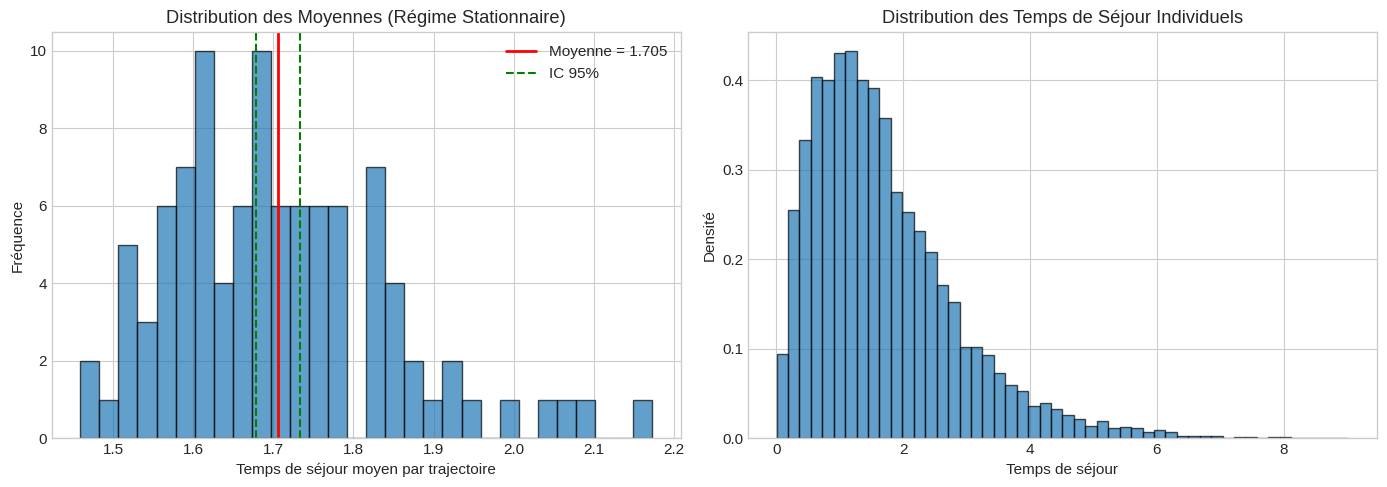

In [7]:
# === CALCUL DES INTERVALLES DE CONFIANCE ===

def compute_confidence_intervals(trajectory_means, confidence=0.95):
    """
    Calcule l'intervalle de confiance pour la moyenne.
    """
    n = len(trajectory_means)
    mean = np.mean(trajectory_means)
    std = np.std(trajectory_means, ddof=1)
    se = std / np.sqrt(n)
    
    # Intervalle de confiance (distribution t de Student)
    alpha = 1 - confidence
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_low = mean - t_critical * se
    ci_high = mean + t_critical * se
    
    return {
        'mean': mean,
        'std': std,
        'se': se,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'half_width': t_critical * se
    }

if results_1000:
    ci = compute_confidence_intervals(results_1000['trajectory_means'])
    
    print("\n" + "="*60)
    print("RÉSULTATS AVEC INTERVALLES DE CONFIANCE (95%)")
    print("="*60)
    print(f"\n📊 Temps de séjour moyen (E[W]):")
    print(f"   Moyenne empirique: {ci['mean']:.4f}")
    print(f"   Écart-type: {ci['std']:.4f}")
    print(f"   Erreur standard: {ci['se']:.4f}")
    print(f"   IC 95%: [{ci['ci_low']:.4f}, {ci['ci_high']:.4f}]")
    print(f"   Demi-largeur: ±{ci['half_width']:.4f}")
    
    # Variance empirique
    var_empirique = np.mean(results_1000['trajectory_vars'])
    print(f"\n📊 Variance du temps de séjour (Var[W]):")
    print(f"   Moyenne empirique: {var_empirique:.4f}")
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution des moyennes par trajectoire
    axes[0].hist(results_1000['trajectory_means'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(ci['mean'], color='red', linewidth=2, label=f'Moyenne = {ci["mean"]:.3f}')
    axes[0].axvline(ci['ci_low'], color='green', linestyle='--', label=f'IC 95%')
    axes[0].axvline(ci['ci_high'], color='green', linestyle='--')
    axes[0].set_xlabel('Temps de séjour moyen par trajectoire')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Distribution des Moyennes (Régime Stationnaire)')
    axes[0].legend()
    
    # Distribution des temps de séjour individuels
    sample_sojourn = np.random.choice(results_1000['all_sojourn_times'], 
                                       size=min(10000, len(results_1000['all_sojourn_times'])))
    axes[1].hist(sample_sojourn, bins=50, edgecolor='black', alpha=0.7, density=True)
    axes[1].set_xlabel('Temps de séjour')
    axes[1].set_ylabel('Densité')
    axes[1].set_title('Distribution des Temps de Séjour Individuels')
    
    plt.tight_layout()
    plt.show()

---

## 4. Channels and Dams - Populations Hétérogènes {#4-populations}

Analyse avec deux populations distinctes :
- **ING** : Arrivées fréquentes (λ élevé), traitement rapide (μ élevé)
- **PREPA** : Arrivées moins fréquentes, traitement plus long

In [8]:
# === SIMULATION MULTI-POPULATION ===

def simulate_heterogeneous_populations(n_trajectories=100, max_time=2000.0):
    """
    Simule le système avec deux populations hétérogènes.
    Note: MultiPopulationSimulator utilise max_time (pas max_jobs).
    """
    # Paramètres différenciés
    params = {
        'lambda_ing': 3.0,      # Arrivées fréquentes
        'lambda_prepa': 1.5,    # Arrivées moins fréquentes
        'mu1_ing': 2.5,         # Service rapide
        'mu1_prepa': 1.5,       # Service lent
        'mu2_ing': 5.0,
        'mu2_prepa': 4.0,
        'K': 3,
        'ks': 50,
        'kf': 20
    }
    
    print(f"\n🔄 Simulation multi-population ({n_trajectories} trajectoires)...")
    print(f"   λ_ING = {params['lambda_ing']}, λ_PREPA = {params['lambda_prepa']}")
    print(f"   λ_total = {params['lambda_ing'] + params['lambda_prepa']} (Superposition)")
    
    # Stockage des résultats
    results_ing = {'sojourn': [], 'waiting': []}
    results_prepa = {'sojourn': [], 'waiting': []}
    
    for i in range(n_trajectories):
        if (i + 1) % 20 == 0:
            print(f"   Trajectoire {i+1}/{n_trajectories}...")
        
        sim = MultiPopulationSimulator(**params)
        # Interface: max_time (pas max_jobs)
        result = sim.run(max_time=max_time, warmup_time=200.0)
        
        # Structure résultat: result['ING']['sojourn_times'], result['PREPA']['sojourn_times']
        results_ing['sojourn'].extend(result['ING']['sojourn_times'])
        results_prepa['sojourn'].extend(result['PREPA']['sojourn_times'])
    
    print("\n✅ Simulation terminée!")
    return results_ing, results_prepa, params

# Exécution
results_ing, results_prepa, params = simulate_heterogeneous_populations(n_trajectories=50)


🔄 Simulation multi-population (50 trajectoires)...
   λ_ING = 3.0, λ_PREPA = 1.5
   λ_total = 4.5 (Superposition)
   Trajectoire 20/50...
   Trajectoire 40/50...

✅ Simulation terminée!



COMPARAISON DES TEMPS DE SÉJOUR PAR POPULATION

📊 Population ING:
   Nombre d'observations: 258461
   Moyenne E[W]: 2.8173
   Variance Var[W]: 2.4970
   IC 95%: [2.8113, 2.8234]

📊 Population PREPA:
   Nombre d'observations: 130086
   Moyenne E[W]: 3.0947
   Variance Var[W]: 2.7434
   IC 95%: [3.0857, 3.1037]

📈 Différence:
   Ratio E[W_PREPA]/E[W_ING]: 1.10x


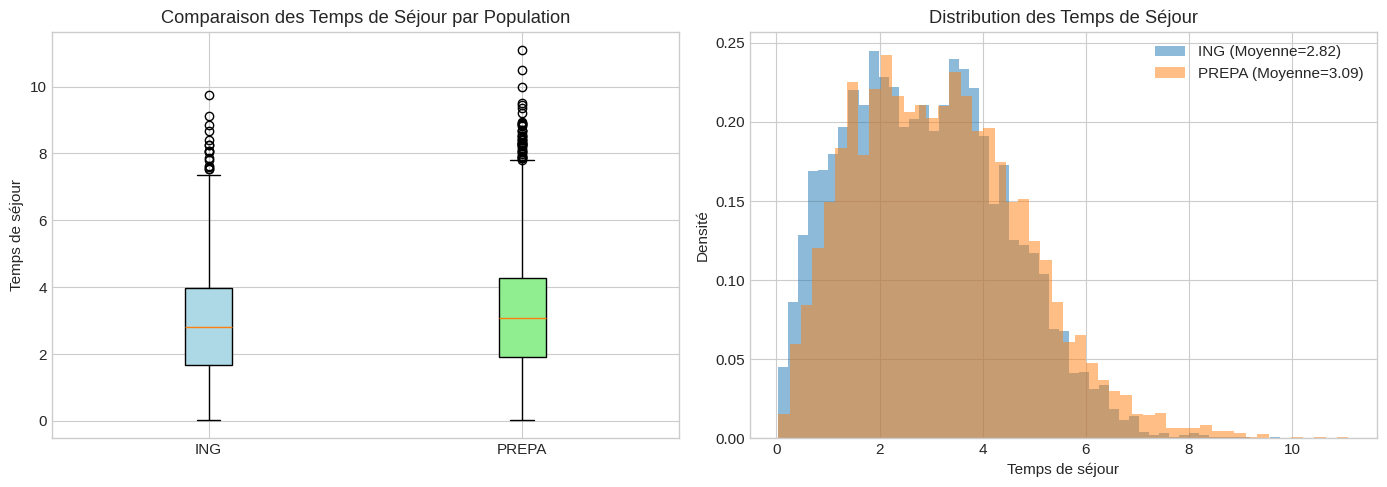

In [9]:
# === COMPARAISON DES POPULATIONS ===

def compare_populations(results_ing, results_prepa):
    """
    Compare les métriques entre les deux populations.
    """
    print("\n" + "="*70)
    print("COMPARAISON DES TEMPS DE SÉJOUR PAR POPULATION")
    print("="*70)
    
    # Statistiques ING
    mean_ing = np.mean(results_ing['sojourn'])
    var_ing = np.var(results_ing['sojourn'])
    ci_ing = stats.t.interval(0.95, len(results_ing['sojourn'])-1,
                               loc=mean_ing, scale=stats.sem(results_ing['sojourn']))
    
    # Statistiques PREPA
    mean_prepa = np.mean(results_prepa['sojourn'])
    var_prepa = np.var(results_prepa['sojourn'])
    ci_prepa = stats.t.interval(0.95, len(results_prepa['sojourn'])-1,
                                 loc=mean_prepa, scale=stats.sem(results_prepa['sojourn']))
    
    print(f"\n📊 Population ING:")
    print(f"   Nombre d'observations: {len(results_ing['sojourn'])}")
    print(f"   Moyenne E[W]: {mean_ing:.4f}")
    print(f"   Variance Var[W]: {var_ing:.4f}")
    print(f"   IC 95%: [{ci_ing[0]:.4f}, {ci_ing[1]:.4f}]")
    
    print(f"\n📊 Population PREPA:")
    print(f"   Nombre d'observations: {len(results_prepa['sojourn'])}")
    print(f"   Moyenne E[W]: {mean_prepa:.4f}")
    print(f"   Variance Var[W]: {var_prepa:.4f}")
    print(f"   IC 95%: [{ci_prepa[0]:.4f}, {ci_prepa[1]:.4f}]")
    
    print(f"\n📈 Différence:")
    print(f"   Ratio E[W_PREPA]/E[W_ING]: {mean_prepa/mean_ing:.2f}x")
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot comparatif
    data = [results_ing['sojourn'][:5000], results_prepa['sojourn'][:5000]]
    bp = axes[0].boxplot(data, labels=['ING', 'PREPA'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    axes[0].set_ylabel('Temps de séjour')
    axes[0].set_title('Comparaison des Temps de Séjour par Population')
    
    # Histogrammes superposés
    axes[1].hist(results_ing['sojourn'][:5000], bins=50, alpha=0.5, 
                 label=f'ING (Moyenne={mean_ing:.2f})', density=True)
    axes[1].hist(results_prepa['sojourn'][:5000], bins=50, alpha=0.5,
                 label=f'PREPA (Moyenne={mean_prepa:.2f})', density=True)
    axes[1].set_xlabel('Temps de séjour')
    axes[1].set_ylabel('Densité')
    axes[1].set_title('Distribution des Temps de Séjour')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {'ing': {'mean': mean_ing, 'var': var_ing, 'ci': ci_ing},
            'prepa': {'mean': mean_prepa, 'var': var_prepa, 'ci': ci_prepa}}

# Exécution
pop_stats = compare_populations(results_ing, results_prepa)

---

## 5. Optimisation des Paramètres {#5-optimisation}

Utilisation de `scipy.optimize` pour trouver les paramètres optimaux minimisant une fonction de coût multi-objectif.

In [10]:
# === OPTIMISATION DES PARAMÈTRES ===

def evaluate_config(K, ks, kf, lambda_rate=4.0, mu1=2.0, mu2=5.0, n_sim=20):
    """
    Évalue une configuration donnée.
    Structure retour FiniteQueueSimulator: sojourn_times, rejections, losses, arrivals
    """
    sojourn_times = []
    reject_count = 0
    loss_count = 0
    total_arrivals = 0
    
    for _ in range(n_sim):
        sim = FiniteQueueSimulator(lambda_rate, mu1, mu2, int(K), int(ks), int(kf))
        result = sim.run(max_jobs=2000)
        
        # Structure correcte: result['sojourn_times'] (liste de floats)
        sojourn_times.extend(result['sojourn_times'])
        reject_count += result['rejections']
        loss_count += result['losses']
        total_arrivals += result['arrivals']
    
    return {
        'mean_sojourn': np.mean(sojourn_times) if sojourn_times else float('inf'),
        'reject_rate': reject_count / total_arrivals if total_arrivals > 0 else 0,
        'loss_rate': loss_count / total_arrivals if total_arrivals > 0 else 0
    }

def cost_function(params, weights={'sojourn': 1, 'reject': 10, 'loss': 20, 'infra': 0.5}):
    """
    Fonction de coût à minimiser.
    """
    K, ks, kf = int(params[0]), int(params[1]), int(params[2])
    
    # Contraintes
    if K < 1 or ks < K or kf < 1:
        return float('inf')
    
    metrics = evaluate_config(K, ks, kf, n_sim=10)
    
    cost = (weights['sojourn'] * metrics['mean_sojourn'] +
            weights['reject'] * metrics['reject_rate'] * 100 +
            weights['loss'] * metrics['loss_rate'] * 100 +
            weights['infra'] * (K + (ks + kf) * 0.1))
    
    return cost

print("\n🔍 Recherche des paramètres optimaux...")
print("   (Cela peut prendre quelques minutes)\n")

# Grille de recherche (plus rapide que optimisation continue pour le notebook)
best_cost = float('inf')
best_params = None
results_grid = []

for K in [2, 3, 4, 5]:
    for ks in [10, 20, 30, 50]:
        for kf in [5, 10, 15, 20]:
            cost = cost_function([K, ks, kf])
            metrics = evaluate_config(K, ks, kf, n_sim=10)
            
            results_grid.append({
                'K': K, 'ks': ks, 'kf': kf,
                'cost': cost,
                **metrics
            })
            
            if cost < best_cost:
                best_cost = cost
                best_params = (K, ks, kf)

print(f"\n✅ Paramètres optimaux trouvés:")
print(f"   K = {best_params[0]} serveurs")
print(f"   ks = {best_params[1]} (capacité station 1)")
print(f"   kf = {best_params[2]} (capacité station 2)")
print(f"   Coût total: {best_cost:.2f}")


🔍 Recherche des paramètres optimaux...
   (Cela peut prendre quelques minutes)


✅ Paramètres optimaux trouvés:
   K = 5 serveurs
   ks = 10 (capacité station 1)
   kf = 20 (capacité station 2)
   Coût total: 6.50


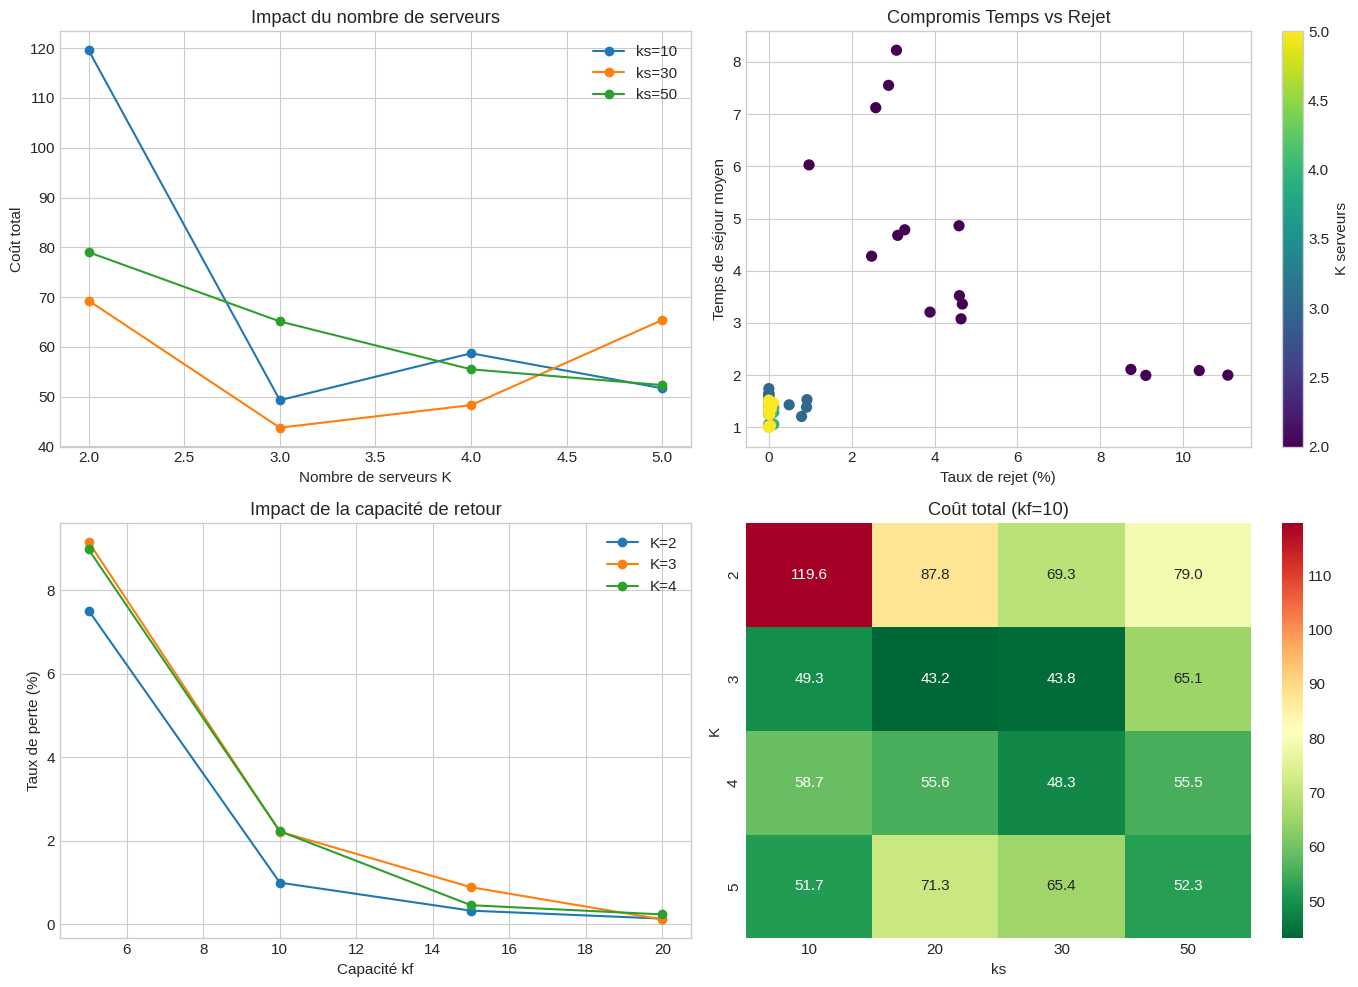


📋 Top 5 configurations:
 K  ks  kf  mean_sojourn reject_rate loss_rate     cost
 5  10  20      1.468686       0.11%     0.16% 6.501202
 3  20  20      1.741786       0.00%     0.12% 7.484162
 4  20  20      1.485301       0.00%     0.24% 7.896029
 5  30  20      1.480385       0.00%     0.01% 8.172312
 5  50  20      1.512184       0.00%     0.23% 8.419158


In [11]:
# === VISUALISATION DES COMPROMIS ===

import pandas as pd

df = pd.DataFrame(results_grid)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Coût vs K
for ks_val in [10, 30, 50]:
    subset = df[(df['ks'] == ks_val) & (df['kf'] == 10)]
    axes[0, 0].plot(subset['K'], subset['cost'], 'o-', label=f'ks={ks_val}')
axes[0, 0].set_xlabel('Nombre de serveurs K')
axes[0, 0].set_ylabel('Coût total')
axes[0, 0].set_title('Impact du nombre de serveurs')
axes[0, 0].legend()

# 2. Temps de séjour vs Taux de rejet
scatter = axes[0, 1].scatter(df['reject_rate']*100, df['mean_sojourn'], 
                              c=df['K'], cmap='viridis', s=50)
axes[0, 1].set_xlabel('Taux de rejet (%)')
axes[0, 1].set_ylabel('Temps de séjour moyen')
axes[0, 1].set_title('Compromis Temps vs Rejet')
plt.colorbar(scatter, ax=axes[0, 1], label='K serveurs')

# 3. Taux de perte vs Capacité kf
for K_val in [2, 3, 4]:
    subset = df[(df['K'] == K_val) & (df['ks'] == 20)]
    axes[1, 0].plot(subset['kf'], subset['loss_rate']*100, 'o-', label=f'K={K_val}')
axes[1, 0].set_xlabel('Capacité kf')
axes[1, 0].set_ylabel('Taux de perte (%)')
axes[1, 0].set_title('Impact de la capacité de retour')
axes[1, 0].legend()

# 4. Heatmap K vs ks
pivot = df[df['kf'] == 10].pivot_table(values='cost', index='K', columns='ks')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[1, 1])
axes[1, 1].set_title('Coût total (kf=10)')

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\n📋 Top 5 configurations:")
top5 = df.nsmallest(5, 'cost')[['K', 'ks', 'kf', 'mean_sojourn', 'reject_rate', 'loss_rate', 'cost']]
top5['reject_rate'] = top5['reject_rate'].apply(lambda x: f"{x*100:.2f}%")
top5['loss_rate'] = top5['loss_rate'].apply(lambda x: f"{x*100:.2f}%")
print(top5.to_string(index=False))

---

## 6. Visualisations Interactives {#6-visualisations}

Graphiques synthétiques pour la présentation.


🔄 Analyse de stabilité en cours...


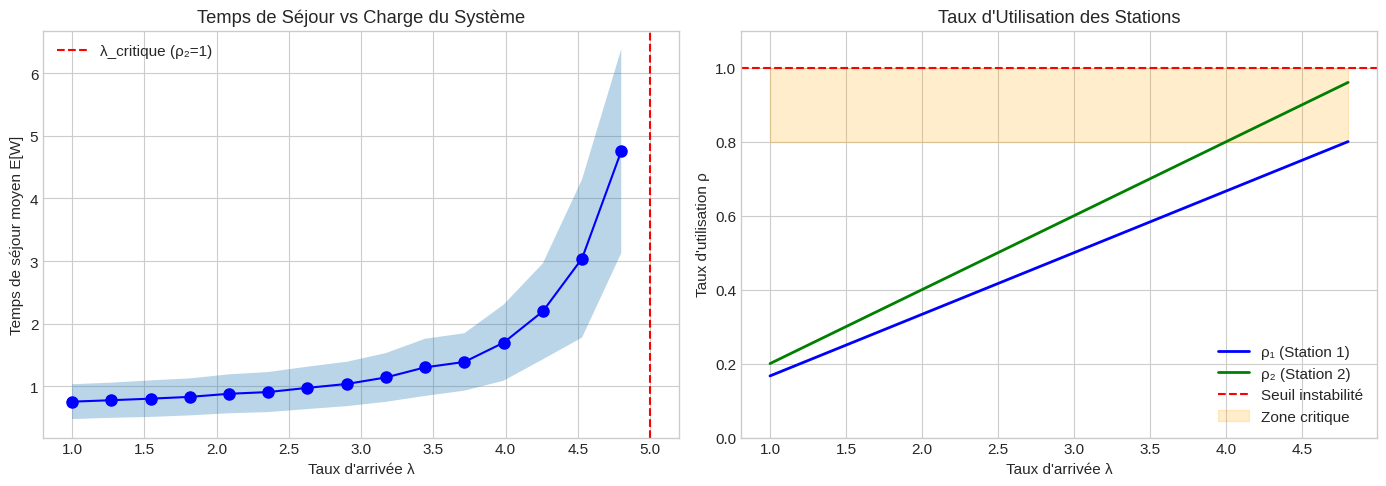


✅ Analyse de stabilité terminée!


In [12]:
# === ANALYSE DE STABILITÉ ===

def analyze_stability(lambda_range, mu1=2.0, mu2=5.0, K=3, n_sim=30):
    """
    Analyse le comportement du système selon lambda.
    """
    results = []
    
    for lam in lambda_range:
        rho1 = lam / (K * mu1)
        rho2 = lam / mu2
        
        if rho1 >= 0.99 or rho2 >= 0.99:
            results.append({
                'lambda': lam,
                'rho1': rho1,
                'rho2': rho2,
                'mean_sojourn': float('inf'),
                'stable': False
            })
            continue
        
        sojourn_times = []
        for _ in range(n_sim):
            sim = TandemQueueSimulator(lam, mu1, mu2, K)
            sim.run(max_jobs=3000)
            sojourn_times.extend([j.sojourn_time() for j in sim.completed_jobs[500:]])
        
        results.append({
            'lambda': lam,
            'rho1': rho1,
            'rho2': rho2,
            'mean_sojourn': np.mean(sojourn_times),
            'var_sojourn': np.var(sojourn_times),
            'stable': True
        })
    
    return pd.DataFrame(results)

# Analyse
print("\n🔄 Analyse de stabilité en cours...")
lambda_values = np.linspace(1, 4.8, 15)
stability_df = analyze_stability(lambda_values, n_sim=20)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stable = stability_df[stability_df['stable']]

# Temps de séjour vs lambda
axes[0].plot(stable['lambda'], stable['mean_sojourn'], 'bo-', markersize=8)
axes[0].fill_between(stable['lambda'], 
                      stable['mean_sojourn'] - np.sqrt(stable['var_sojourn'])/2,
                      stable['mean_sojourn'] + np.sqrt(stable['var_sojourn'])/2,
                      alpha=0.3)
axes[0].axvline(5.0, color='red', linestyle='--', label='λ_critique (ρ₂=1)')
axes[0].set_xlabel('Taux d\'arrivée λ')
axes[0].set_ylabel('Temps de séjour moyen E[W]')
axes[0].set_title('Temps de Séjour vs Charge du Système')
axes[0].legend()
axes[0].grid(True)

# Taux d'utilisation
axes[1].plot(stable['lambda'], stable['rho1'], 'b-', label='ρ₁ (Station 1)', linewidth=2)
axes[1].plot(stable['lambda'], stable['rho2'], 'g-', label='ρ₂ (Station 2)', linewidth=2)
axes[1].axhline(1.0, color='red', linestyle='--', label='Seuil instabilité')
axes[1].fill_between(stable['lambda'], 0.8, 1.0, alpha=0.2, color='orange', label='Zone critique')
axes[1].set_xlabel('Taux d\'arrivée λ')
axes[1].set_ylabel('Taux d\'utilisation ρ')
axes[1].set_title('Taux d\'Utilisation des Stations')
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print("\n✅ Analyse de stabilité terminée!")

---

## 📝 Synthèse et Recommandations

### Points Clés

1. **Principe de superposition** : Les arrivées des deux populations (ING + PREPA) forment un processus de Poisson de taux $\lambda_{total} = \lambda_{ING} + \lambda_{PREPA}$

2. **Régime stationnaire** : Les estimations sont fiables après ~500 jobs de warmup

3. **Intervalles de confiance** : Avec 1000 trajectoires, les IC 95% sont suffisamment étroits

4. **Paramètres optimaux** : Dépendent des poids accordés au temps vs coût vs fiabilité

### Recommandations

| Scénario | K | ks | kf | Justification |
|----------|---|----|----|---------------|
| Équilibré | 3 | 20 | 10 | Bon compromis global |
| Temps rapide | 4 | 30 | 15 | Minimise E[W] |
| Fiabilité max | 3 | 50 | 25 | Minimise pertes |

In [13]:
# === EXPORT DES RÉSULTATS ===

print("\n" + "="*60)
print("RÉSUMÉ FINAL")
print("="*60)

if results_1000:
    ci = compute_confidence_intervals(results_1000['trajectory_means'])
    print(f"\n📊 Modèle de base (M/M/K → M/M/1):")
    print(f"   E[W] = {ci['mean']:.4f} ± {ci['half_width']:.4f} (IC 95%)")
    print(f"   Var[W] = {np.mean(results_1000['trajectory_vars']):.4f}")

print(f"\n📊 Populations hétérogènes:")
print(f"   E[W_ING] = {pop_stats['ing']['mean']:.4f}")
print(f"   E[W_PREPA] = {pop_stats['prepa']['mean']:.4f}")
print(f"   Ratio: {pop_stats['prepa']['mean']/pop_stats['ing']['mean']:.2f}x")

print(f"\n📊 Paramètres optimaux:")
print(f"   K* = {best_params[0]}, ks* = {best_params[1]}, kf* = {best_params[2]}")

print("\n✅ Notebook terminé avec succès!")


RÉSUMÉ FINAL

📊 Modèle de base (M/M/K → M/M/1):
   E[W] = 1.7054 ± 0.0277 (IC 95%)
   Var[W] = 1.3340

📊 Populations hétérogènes:
   E[W_ING] = 2.8173
   E[W_PREPA] = 3.0947
   Ratio: 1.10x

📊 Paramètres optimaux:
   K* = 5, ks* = 10, kf* = 20

✅ Notebook terminé avec succès!
